In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "cleaned_sales_data.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,order_id,customer_id,product_id,product_name,category,city,order_date,quantity,unit_price,total_amount
0,1001,C001,P001,Laptop,Electronics,Pune,2024-01-05,1,55000,55000
1,1002,C002,P002,Mobile Phone,Electronics,Mumbai,2024-01-08,2,25000,50000
2,1003,C003,P003,Headphones,Electronics,Nashik,2024-01-15,3,1500,4500
3,1004,C004,P004,Running Shoes,Sports,Pune,2024-01-20,2,3000,6000
4,1005,C005,P005,Cricket Bat,Sports,Mumbai,2024-01-25,1,4500,4500


In [2]:
total_sales = df["total_amount"].sum()

print("Total Sales:", total_sales)

Total Sales: 422100


In [3]:
average_order_value = df["total_amount"].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 11725.0


In [4]:
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()

print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)

Total Orders: 36
Total Quantity Sold: 67


In [5]:
top_products = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_products)

product_name
Laptop          110000
Mobile Phone     50000
Monitor          36000
Bed              30000
Sofa             25000
Name: total_amount, dtype: int64


In [6]:
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
Electronics    236100
Furniture      114500
Sports          29600
Clothing        28700
Books           13200
Name: total_amount, dtype: int64


order_date
2024-01    120000
2024-02     32900
2024-03     35500
2024-04     45900
2024-05     42000
2024-06     58200
2024-07     61000
2024-08     11100
2024-09      3500
2024-10     12000
Name: total_amount, dtype: int64


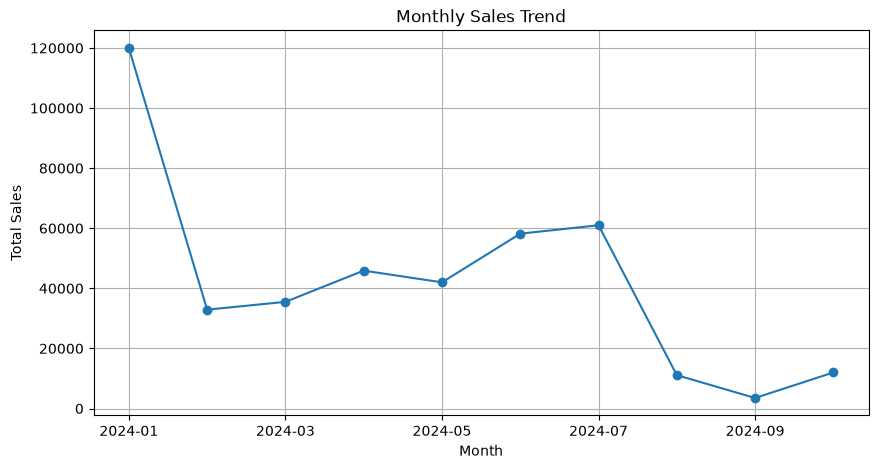

In [8]:
monthly_sales = (
    df.groupby(df["order_date"].str[:7])["total_amount"]
    .sum()
)

print(monthly_sales)

monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

city
Pune      189200
Mumbai    116700
Nashik    116200
Name: total_amount, dtype: int64


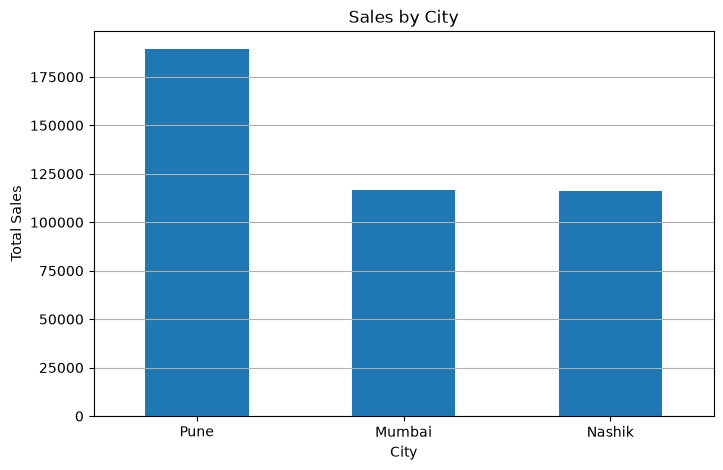

In [10]:
city_sales = (
    df.groupby("city")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales)

city_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Sales by City"
)

plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

category
Electronics    236100
Furniture      114500
Sports          29600
Clothing        28700
Books           13200
Name: total_amount, dtype: int64


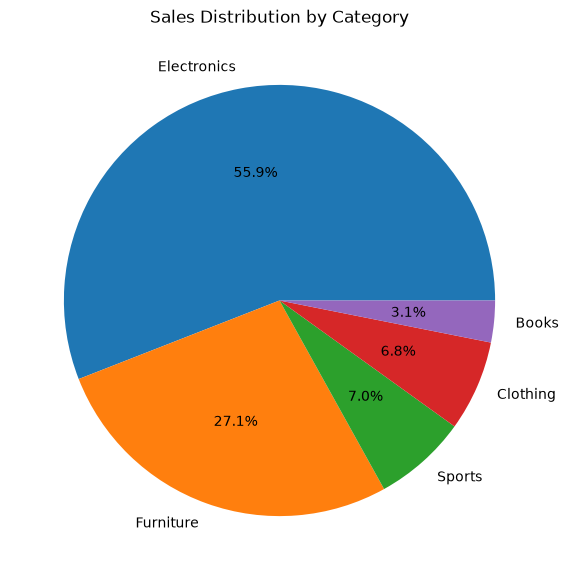

In [12]:
category_sales = (
    df.groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7),
    title="Sales Distribution by Category"
)

plt.ylabel("")
plt.show()

product_name
Laptop          110000
Mobile Phone     50000
Monitor          36000
Bed              30000
Sofa             25000
Name: total_amount, dtype: int64


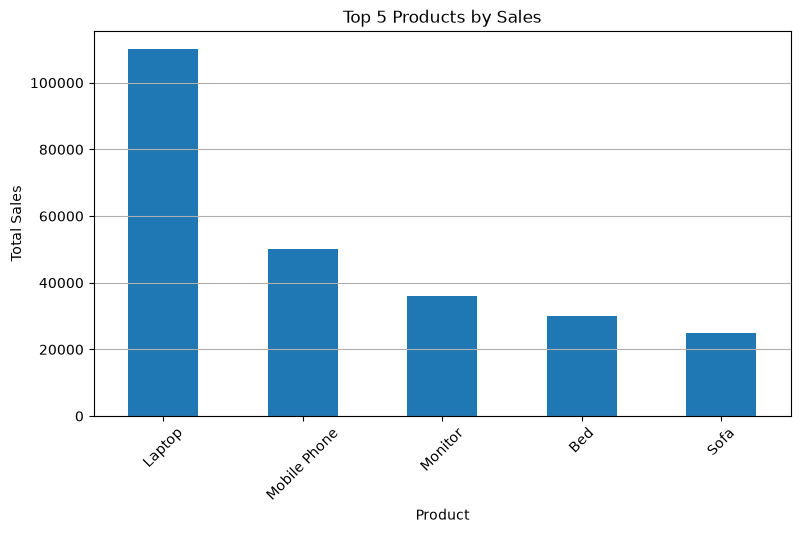

In [14]:
top_products = (
    df.groupby("product_name")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top_products)

top_products.plot(
    kind="bar",
    figsize=(9, 5),
    title="Top 5 Products by Sales"
)

plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [15]:
total_sales = df["total_amount"].sum()
average_order_value = df["total_amount"].mean()
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()
unique_customers = df["customer_id"].nunique()
unique_products = df["product_id"].nunique()

print("===== SALES SUMMARY =====")
print("Total Sales:", total_sales)
print("Average Order Value:", round(average_order_value, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Unique Customers:", unique_customers)
print("Unique Products:", unique_products)

===== SALES SUMMARY =====
Total Sales: 422100
Average Order Value: 11725.0
Total Orders: 36
Total Quantity Sold: 67
Unique Customers: 10
Unique Products: 30


In [16]:
output_path = BASE_DIR / "data" / "processed" / "analysis_results.csv"

df.to_csv(output_path, index=False)

print("Analysis results exported successfully.")
print(output_path)

Analysis results exported successfully.
c:\Users\Radhika\OneDrive\Documents\Arena internship\week7-sales-analysis\data\processed\analysis_results.csv


In [17]:
print("========== SALES ANALYSIS REPORT ==========")

print("\n1. Overall Performance")
print("Total Sales:", total_sales)
print("Average Order Value:", round(average_order_value, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)

print("\n2. Customer & Product Information")
print("Unique Customers:", unique_customers)
print("Unique Products:", unique_products)

print("\n3. Top 5 Products")
print(top_products)

print("\n4. Sales by Category")
print(category_sales)

print("\n5. Sales by City")
print(city_sales)

print("\n6. Monthly Sales")
print(monthly_sales)

print("\n========== REPORT COMPLETED ==========")

========== SALES ANALYSIS REPORT ==========

1. Overall Performance
Total Sales: 422100
Average Order Value: 11725.0
Total Orders: 36
Total Quantity Sold: 67

2. Customer & Product Information
Unique Customers: 10
Unique Products: 30

3. Top 5 Products
product_name
Laptop          110000
Mobile Phone     50000
Monitor          36000
Bed              30000
Sofa             25000
Name: total_amount, dtype: int64

4. Sales by Category
category
Electronics    236100
Furniture      114500
Sports          29600
Clothing        28700
Books           13200
Name: total_amount, dtype: int64

5. Sales by City
city
Pune      189200
Mumbai    116700
Nashik    116200
Name: total_amount, dtype: int64

6. Monthly Sales
order_date
2024-01    120000
2024-02     32900
2024-03     35500
2024-04     45900
2024-05     42000
2024-06     58200
2024-07     61000
2024-08     11100
2024-09      3500
2024-10     12000
Name: total_amount, dtype: int64

========== REPORT COMPLETED ==========


In [18]:
summary_data = {
    "Metric": [
        "Total Sales",
        "Average Order Value",
        "Total Orders",
        "Total Quantity Sold",
        "Unique Customers",
        "Unique Products"
    ],
    "Value": [
        total_sales,
        round(average_order_value, 2),
        total_orders,
        total_quantity,
        unique_customers,
        unique_products
    ]
}

summary_df = pd.DataFrame(summary_data)

summary_path = BASE_DIR / "data" / "processed" / "sales_summary.csv"

summary_df.to_csv(summary_path, index=False)

print("Final summary exported successfully.")
print(summary_path)

summary_df

Final summary exported successfully.
c:\Users\Radhika\OneDrive\Documents\Arena internship\week7-sales-analysis\data\processed\sales_summary.csv


,Metric,Value
0,Total Sales,422100.0
1,Average Order Value,11725.0
2,Total Orders,36.0
3,Total Quantity Sold,67.0
4,Unique Customers,10.0
5,Unique Products,30.0
